# Leukemia Classification using EfficientNetB0


In [1]:

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model


2026-04-05 15:25:29.632394: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775402729.987989      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775402730.132522      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775402731.270397      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775402731.270461      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775402731.270464      24 computation_placer.cc:177] computation placer alr

In [2]:
from tensorflow.keras.applications import EfficientNetB0

In [3]:

dataset_path = "/kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)"
classes = os.listdir(dataset_path)
print("Classes:", classes)

images = []
labels = []

for c in classes:
    folder = os.path.join(dataset_path, c)
    for img in os.listdir(folder):
        images.append(os.path.join(folder, img))
        labels.append(c)

df = pd.DataFrame({"image": images, "label": labels})
print("Total images:", len(df))


Classes: ['all', 'normal']
Total images: 10661


In [4]:

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)


In [5]:

img_size = (224,224)
batch_size = 32

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(
    train_df, x_col="image", y_col="label",
    target_size=img_size, class_mode="categorical",
    batch_size=batch_size)

val_data = val_gen.flow_from_dataframe(
    val_df, x_col="image", y_col="label",
    target_size=img_size, class_mode="categorical",
    batch_size=batch_size)

test_data = test_gen.flow_from_dataframe(
    test_df, x_col="image", y_col="label",
    target_size=img_size, class_mode="categorical",
    shuffle=False)


Found 7462 validated image filenames belonging to 2 classes.
Found 1599 validated image filenames belonging to 2 classes.
Found 1600 validated image filenames belonging to 2 classes.


In [6]:

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(len(classes), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


I0000 00:00:1775402776.694517      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,797 (16.07 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [7]:

start = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

training_time = time.time() - start
print("Training Time:", training_time)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1775402790.670832      66 service.cc:152] XLA service 0x7c9c48003d00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775402790.670866      66 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775402792.892764      66 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775402803.628345      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


234/234 ━━━━━━━━━━━━━━━━━━━━ 103s 343ms/step - accuracy: 0.6734 - loss: 0.6388 - val_accuracy: 0.6823 - val_loss: 0.6468
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - accuracy: 0.6764 - loss: 0.6405 - val_accuracy: 0.6823 - val_loss: 0.6297
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - accuracy: 0.6756 - loss: 0.6367 - val_accuracy: 0.6823 - val_loss: 0.6274
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.6903 - loss: 0.6205 - val_accuracy: 0.6823 - val_loss: 0.6276
Epoch 5/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - accuracy: 0.6827 - loss: 0.6271 - val_accuracy: 0.6823 - val_loss: 0.6251
Epoch 6/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.6785 - loss: 0.6290 - val_accuracy: 0.6823 - val_loss: 0.6270
Epoch 7/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - accuracy: 0.6820 - loss: 0.6264 - val_accuracy: 0.6823 - val_loss: 0.6287
Epoch 8/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - accuracy: 0.6726 - loss: 0.6332 - val_accur

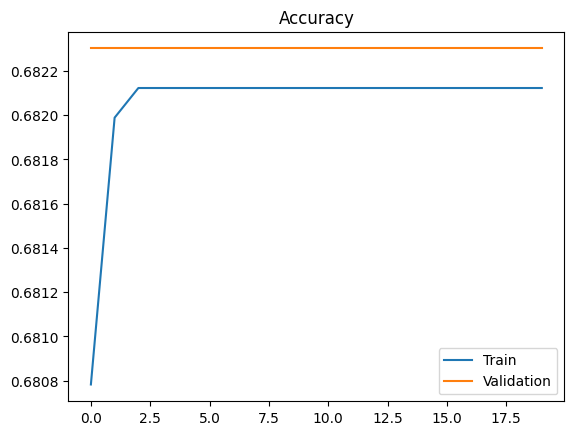

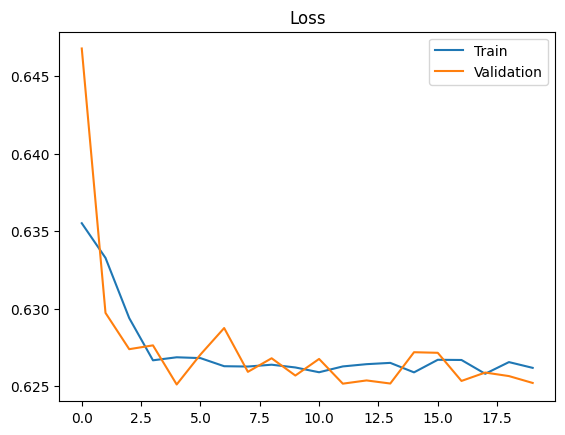

In [8]:

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])
plt.show()


In [9]:

start = time.time()
pred = model.predict(test_data)
testing_time = time.time() - start

print("Testing Time:", testing_time)

y_pred = np.argmax(pred, axis=1)
y_true = test_data.classes

print(classification_report(y_true, y_pred))

test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", test_acc)


50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 189ms/step
Testing Time: 15.654340744018555
              precision    recall  f1-score   support

           0       0.68      1.00      0.81      1091
           1       0.00      0.00      0.00       509

    accuracy                           0.68      1600
   macro avg       0.34      0.50      0.41      1600
weighted avg       0.46      0.68      0.55      1600

Test Accuracy: 0.681875


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
